In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

df.columns = df.columns.str.strip()
df = df.dropna(how="all")
df = df.drop_duplicates()

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype("string").str.strip()

for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col], errors="coerce")
    elif col.lower() in {"quantity", "price", "amount", "sales", "revenue"}:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "City" in df.columns:
    df["City"] = df["City"].replace({"Bangalore": "Bengaluru"})

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    elif not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = df[col].fillna("Unknown")

for col in [c for c in df.columns if "date" in c.lower()]:
    df = df.dropna(subset=[col])

for col in df.columns:
    if col.lower() in {"quantity", "price", "amount", "sales", "revenue"}:
        df.loc[df[col] <= 0, col] = np.nan
        df[col] = df[col].fillna(df[col].median())

for col in [c for c in df.columns if "id" in c.lower()]:
    df = df.drop_duplicates(subset=[col], keep="first")

df.to_excel("/content/Cleaned_Dataset.xlsx", index=False)
print("Cleaning completed successfully.")
print("Final shape:", df.shape)

print("First 10 rows of cleaned data:")
display(df.head(10))

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)


Cleaning completed successfully.
Final shape: (1189, 14)
First 10 rows of cleaned data:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2.0,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1.0,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5.0,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2.0,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,Unknown,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4.0,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52



Dataset Shape: (1189, 14)

Missing Values:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

Duplicate Rows: 0

Data Types:
OrderID            string[python]
Date               datetime64[ns]
CustomerID         string[python]
Product            string[python]
Quantity                  float64
UnitPrice                 float64
ShippingAddress    string[python]
PaymentMethod      string[python]
OrderStatus        string[python]
TrackingNumber     string[python]
ItemsInCart                 int64
CouponCode         string[python]
ReferralSource     string[python]
TotalPrice                float64
dtype: object



========== FIRST 10 ROWS ==========
     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   
5  ORD200005  2023-10-23     C37249    Phone         2     245.86   
6  ORD200006  2025-06-17     C83492   Laptop         1     664.42   
7  ORD200007  2023-05-12     C41460  Monitor         5     149.55   
8  ORD200008  2025-04-02     C26817    Phone         2     134.28   
9  ORD200009  2023-11-21     C31946     Desk         4     509.38   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK911

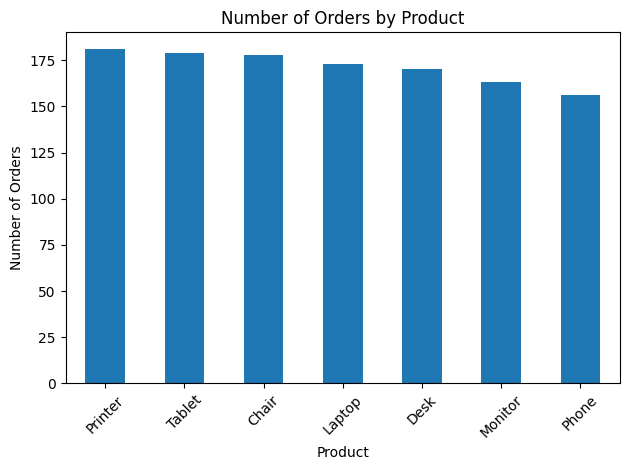

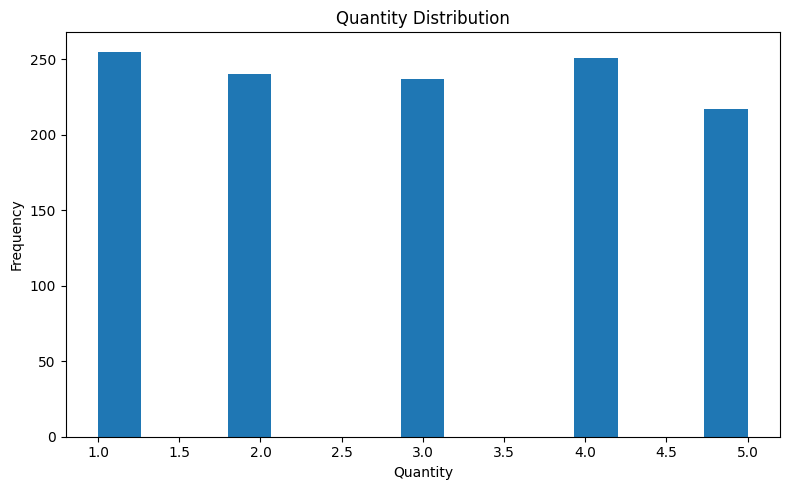


========== MONTHLY ORDER TREND ==========
Date
2023-01    47
2023-02    37
2023-03    43
2023-04    31
2023-05    49
2023-06    45
2023-07    44
2023-08    51
2023-09    29
2023-10    47
2023-11    41
2023-12    46
2024-01    32
2024-02    32
2024-03    36
2024-04    50
2024-05    34
2024-06    53
2024-07    43
2024-08    28
2024-09    44
2024-10    31
2024-11    35
2024-12    41
2025-01    27
2025-02    37
2025-03    49
2025-04    32
2025-05    37
2025-06    49
Freq: M, dtype: int64


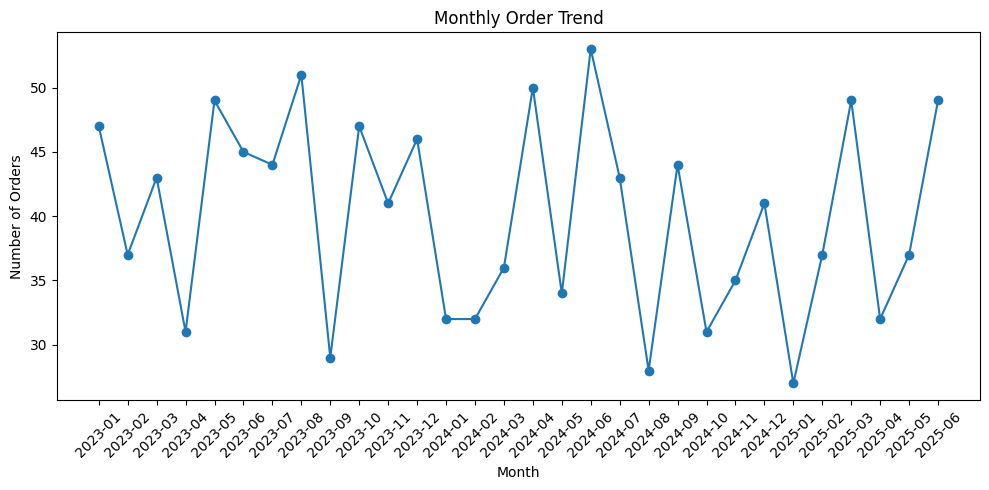


========== CORRELATION MATRIX ==========
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


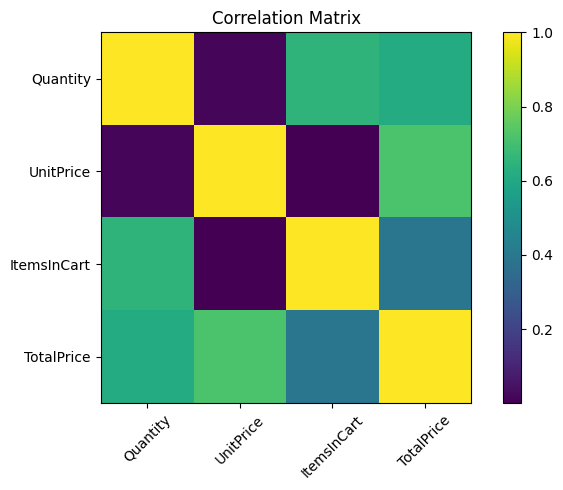


KEY OBSERVATIONS
1. Product with the highest number of orders: Printer
3. Average quantity: 2.9458333333333333
4. Median quantity: 3.0

EDA COMPLETED SUCCESSFULLY!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

print("\n========== FIRST 10 ROWS ==========")
print(df.head(10))

print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

df.columns = df.columns.str.strip()

date_cols = [col for col in df.columns if "date" in col.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in df.columns:
    if col.lower() in ["quantity", "price", "amount", "sales", "revenue"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

numeric_cols = df.select_dtypes(include=np.number).columns

print("\n========== COUNT ==========")
print(df[numeric_cols].count())

print("\n========== MEAN ==========")
print(df[numeric_cols].mean())

print("\n========== MEDIAN ==========")
print(df[numeric_cols].median())

print("\n========== MINIMUM ==========")
print(df[numeric_cols].min())

print("\n========== MAXIMUM ==========")
print(df[numeric_cols].max())

print("\n========== OUTLIER ANALYSIS ==========")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print("\nColumn:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))

if "Product" in df.columns:

    print("\n========== PRODUCT ANALYSIS ==========")
    print(df["Product"].value_counts())

    df["Product"].value_counts().plot(kind="bar")

    plt.title("Number of Orders by Product")
    plt.xlabel("Product")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if "City" in df.columns:

    print("\n========== CITY ANALYSIS ==========")
    print(df["City"].value_counts())

    df["City"].value_counts().plot(kind="bar")

    plt.title("Number of Orders by City")
    plt.xlabel("City")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if "Price" in df.columns:

    plt.figure(figsize=(8, 5))
    plt.hist(df["Price"].dropna(), bins=20)

    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

if "Price" in df.columns:

    plt.figure(figsize=(6, 5))
    plt.boxplot(df["Price"].dropna())

    plt.title("Price Box Plot")
    plt.ylabel("Price")
    plt.show()

if "Quantity" in df.columns:

    plt.figure(figsize=(8, 5))
    plt.hist(df["Quantity"].dropna(), bins=15)

    plt.title("Quantity Distribution")
    plt.xlabel("Quantity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

if len(date_cols) > 0:

    date_col = date_cols[0]

    monthly_orders = (
        df.dropna(subset=[date_col])
        .groupby(df[date_col].dt.to_period("M"))
        .size()
    )

    print("\n========== MONTHLY ORDER TREND ==========")
    print(monthly_orders)

    monthly_orders.index = monthly_orders.index.astype(str)

    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_orders.index,
        monthly_orders.values,
        marker="o"
    )

    plt.title("Monthly Order Trend")
    plt.xlabel("Month")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if len(numeric_cols) >= 2:

    print("\n========== CORRELATION MATRIX ==========")

    correlation = df[numeric_cols].corr()

    print(correlation)

    plt.figure(figsize=(7, 5))
    plt.imshow(correlation)
    plt.colorbar()

    plt.xticks(
        range(len(numeric_cols)),
        numeric_cols,
        rotation=45
    )

    plt.yticks(
        range(len(numeric_cols)),
        numeric_cols
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

print("\n================================")
print("KEY OBSERVATIONS")
print("================================")

if "Product" in df.columns:

    top_product = df["Product"].value_counts().idxmax()

    print(
        "1. Product with the highest number of orders:",
        top_product
    )

if "City" in df.columns:

    top_city = df["City"].value_counts().idxmax()

    print(
        "2. City with the highest number of orders:",
        top_city
    )

if "Quantity" in df.columns:

    print(
        "3. Average quantity:",
        df["Quantity"].mean()
    )

    print(
        "4. Median quantity:",
        df["Quantity"].median()
    )

if "Price" in df.columns:

    print(
        "5. Average price:",
        df["Price"].mean()
    )

    print(
        "6. Median price:",
        df["Price"].median()
    )

print("\n================================")
print("EDA COMPLETED SUCCESSFULLY!")
print("================================")